In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

features = [
    'age', 
    'ejection_fraction', 
    'serum_creatinine', 
    'serum_sodium', 
    'creatinine_phosphokinase'
]

X = df[features]
y = df['DEATH_EVENT']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=50
)

In [4]:
# 4. Padronização Matemática (Prevenção de Contaminação do Teste)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11]}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

for k, acc in zip(param_grid['n_neighbors'], grid.cv_results_['mean_test_score']):
    print(f"K={k}: {acc:.4f}")

print(f"\nMelhor K: {grid.best_params_['n_neighbors']}")
print(f"Melhor acurácia: {grid.best_score_:.4f}")

K=1: 0.7128
K=3: 0.7317
K=5: 0.7269
K=7: 0.7271
K=9: 0.7606
K=11: 0.7606

Melhor K: 9
Melhor acurácia: 0.7606


In [6]:
knn = grid.best_estimator_

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [7]:
# Impressão das métricas formais
print("\n================ RELATÓRIO DE CLASSIFICAÇÃO ================\n")
print(classification_report(y_test, y_pred, target_names=['Sobrevivência (0)', 'Óbito (1)']))

# Matriz de Confusão detalhada
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n================ MATRIZ DE CONFUSÃO ================")
print(f"Verdadeiros Negativos (Sobreviveram -> Previstos como Sobreviventes): {conf_matrix[0][0]}")
print(f"Falsos Positivos      (Sobreviveram -> Previstos como Óbito): {conf_matrix[0][1]}")
print(f"Falsos Negativos      (Óbito -> Previstos como Sobreviventes): {conf_matrix[1][0]}")
print(f"Verdadeiros Positivos (Óbito -> Previstos como Óbito): {conf_matrix[1][1]}")


================ RELATÓRIO DE CLASSIFICAÇÃO ================

                   precision    recall  f1-score   support

Sobrevivência (0)       0.72      0.90      0.80        61
        Óbito (1)       0.57      0.28      0.37        29

         accuracy                           0.70        90
        macro avg       0.65      0.59      0.59        90
     weighted avg       0.67      0.70      0.66        90


================ MATRIZ DE CONFUSÃO ================
Verdadeiros Negativos (Sobreviveram -> Previstos como Sobreviventes): 55
Falsos Positivos      (Sobreviveram -> Previstos como Óbito): 6
Falsos Negativos      (Óbito -> Previstos como Sobreviventes): 21
Verdadeiros Positivos (Óbito -> Previstos como Óbito): 8


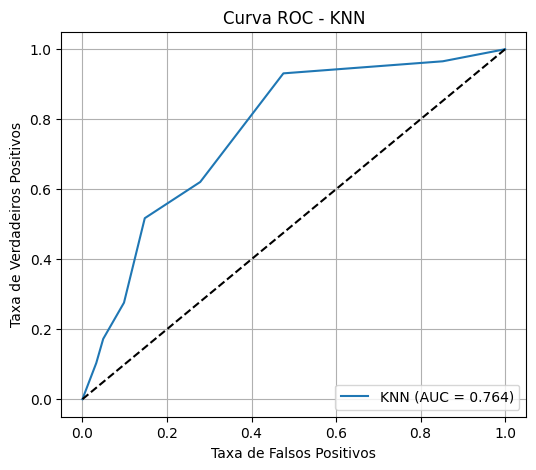

In [8]:
# Probabilidades da classe positiva
y_score_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Curva ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(6,5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - KNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

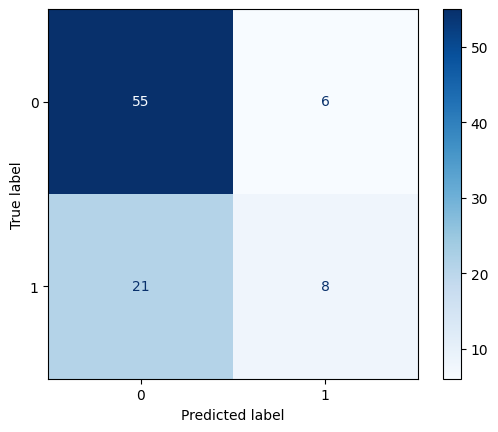

In [9]:
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.show()

In [10]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=50),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_rf.best_params_)

print("\nMelhor F1:")
print(grid_rf.best_score_)

Melhores parâmetros:
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Melhor F1:
0.5768179402362311


In [11]:
rf = grid_rf.best_estimator_

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [12]:
print("\n================ RANDOM FOREST ================\n")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Sobrevivência (0)', 'Óbito (1)']
))

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n================ MATRIZ DE CONFUSÃO ================\n")
print(f"Verdadeiros Negativos: {cm_rf[0][0]}")
print(f"Falsos Positivos:      {cm_rf[0][1]}")
print(f"Falsos Negativos:      {cm_rf[1][0]}")
print(f"Verdadeiros Positivos: {cm_rf[1][1]}")


================ RANDOM FOREST ================

                   precision    recall  f1-score   support

Sobrevivência (0)       0.81      0.84      0.82        61
        Óbito (1)       0.63      0.59      0.61        29

         accuracy                           0.76        90
        macro avg       0.72      0.71      0.71        90
     weighted avg       0.75      0.76      0.75        90


================ MATRIZ DE CONFUSÃO ================

Verdadeiros Negativos: 51
Falsos Positivos:      10
Falsos Negativos:      12
Verdadeiros Positivos: 17


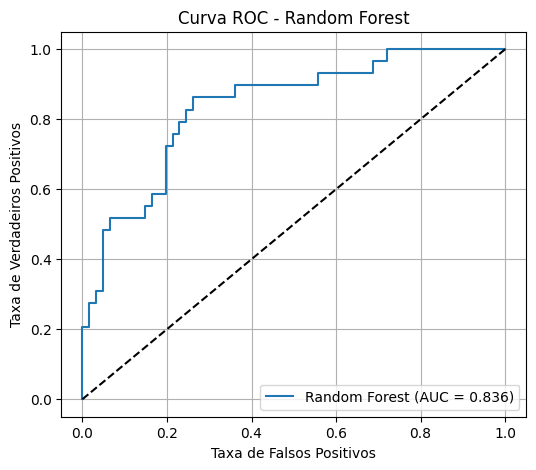

In [15]:
# Probabilidades da classe positiva
y_score_rf = rf.predict_proba(X_test)[:, 1]

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

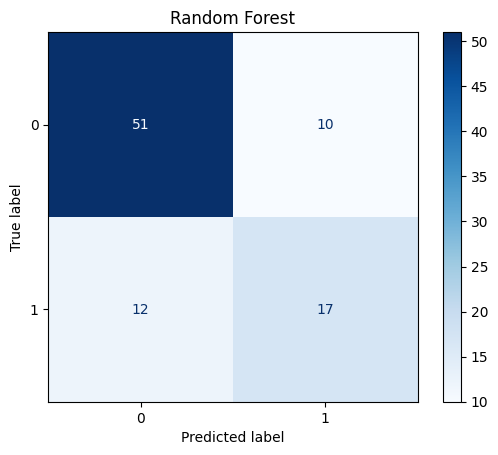

In [13]:
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Blues")
plt.title("Random Forest")
plt.show()

In [14]:
resultado = pd.DataFrame({
    'Modelo': ['KNN', 'Random Forest'],
    'Acurácia': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precisão': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ]
})

print(resultado)

          Modelo  Acurácia  Precisão    Recall  F1-Score
0            KNN  0.700000  0.571429  0.275862  0.372093
1  Random Forest  0.755556  0.629630  0.586207  0.607143


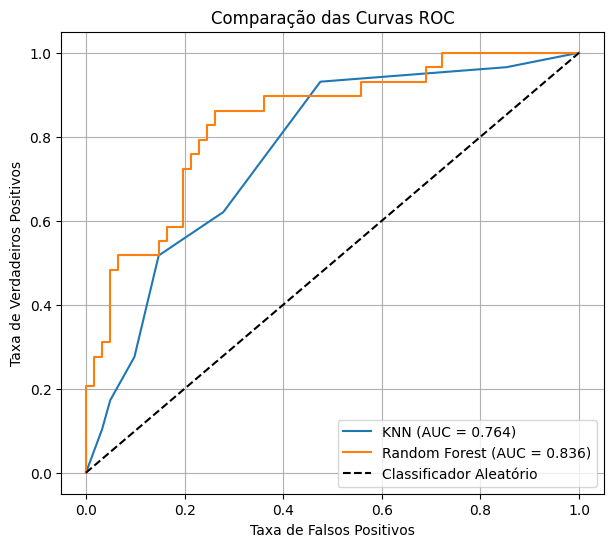

In [16]:
# Probabilidades
y_score_knn = knn.predict_proba(X_test_scaled)[:, 1]
y_score_rf = rf.predict_proba(X_test)[:, 1]

# ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)

auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,6))

plt.plot(fpr_knn, tpr_knn,
         label=f'KNN (AUC = {auc_knn:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Classificador Aleatório')

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Comparação das Curvas ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()